# 03 — LSTM Balance Data - Class Weight
**Tesis Analisis Sentimen Bencana Banjir**

Notebook ini menjalankan eksperimen pemodelan **LSTM** dengan strategi: **Class Weight**.
- **a. Load DF**: Membaca dataframe bersih hasil pra-pemrosesan (`data_clean_final.csv` atau `data_bersih_siap_pakai.csv`).
- **b. Train-Test Split**: Pembagian data stratified terkunci bebas *leakage* (72% Train, 8% Val, 20% Test, `seed=42`).
  - *Highlight*: Highlight Class Weight: Menghitung pembobotan kelas (cost-sensitive learning) menggunakan sklearn compute_class_weight untuk memberi penalti loss lebih tinggi pada kelas minoritas tanpa mengubah jumlah sampel.
- **c. Model LSTM (Komposisi Hyperparameter Tuning)**: Spesifikasi ruang pencarian parameter (*search space*), tabel riwayat tuning empiris (*top trials*), serta penetapan konfigurasi pemenang.
- **d. Evaluasi & Metrik**: Akurasi, Precision, Recall, F1-Score (per kelas & Macro), serta Visualisasi Heatmap Confusion Matrix.


In [1]:
# Setup lingkungan kerja & modul
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score

# TensorFlow & Keras
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Kunci seed deterministik
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

if Path.cwd().name in ["notebooks", "script_thesis"]:
    os.chdir("..")
print("Direktori Kerja:", Path.cwd())


Direktori Kerja: D:\DATA SCIENCE\jokiidin\Thesis-LSTM-IndoBERT


In [2]:
import os
import sys
from pathlib import Path

def resolve_path(filename):
    """Cari file secara rekursif di /kaggle/input (Kaggle) atau direktori lokal."""
    # 1. Rekursif cari di /kaggle/input (Kaggle)
    if Path("/kaggle/input").exists():
        for root, _dirs, files in os.walk("/kaggle/input"):
            if filename in files:
                found = os.path.join(root, filename)
                print(f"[resolve_path] Ditemukan di Kaggle: {found}")
                return found
    # 2. Kandidat lokal workstation / Colab
    candidates = [
        Path(f"Data/processed/{filename}"),
        Path(f"Data/raw/{filename}"),
        Path(f"Data/interim/{filename}"),
        Path(f"Data/{filename}"),
        Path(f"kamus/{filename}"),
        Path(f"Preprocessing/{filename}"),
        Path(f"Output/predictions/{filename}"),
        Path(f"../Data/processed/{filename}"),
        Path(f"../Data/raw/{filename}"),
        Path(f"../Data/interim/{filename}"),
        Path(f"../Data/{filename}"),
        Path(f"../kamus/{filename}"),
        Path(f"../Preprocessing/{filename}"),
        Path(filename),
    ]
    for p in candidates:
        if p.exists():
            print(f"[resolve_path] Ditemukan lokal: {p}")
            return str(p)
    return filename


## a. Load DataFrame Bersih
Membaca dataset bersih siap pakai yang dihasilkan dari tahap pra-pemrosesan.

In [3]:
# a. Load DataFrame Bersih
clean_path = resolve_path("data_clean_final.csv")
if not Path(clean_path).exists():
    clean_path = resolve_path("data_bersih_siap_pakai.csv")
if not Path(clean_path).exists():
    clean_path = resolve_path("banjir_processed_v2.csv")

df = pd.read_csv(clean_path)
col_text = 'clean_text' if 'clean_text' in df.columns else ('processed_text_v2' if 'processed_text_v2' in df.columns else 'text')
col_label = 'label'

print(f"Dataframe dimuat dari: {clean_path}")
print(f"Total baris: {len(df):,} | Kolom teks: '{col_text}' | Kolom label: '{col_label}'")
print("\nDistribusi label:")
print(df[col_label].value_counts().sort_index().to_dict())
display(df.head(3))


[resolve_path] Ditemukan lokal: Data\processed\data_clean_final.csv
Dataframe dimuat dari: Data\processed\data_clean_final.csv
Total baris: 8,648 | Kolom teks: 'clean_text' | Kolom label: 'label'

Distribusi label:
{0: 4686, 1: 1510, 2: 2452}


,text,reconstructed_text,clean_text,label
0,Polisi : Sulit menemukan siapa pemilik kayu yg...,Polisi : Sulit menemukan siapa pemilik kayu yg...,polisi sulit menemukan siapa pemilik kayu meny...,0
1,Seorang Ibu harus memanjat tebing demi membawa...,Seorang Ibu harus memanjat tebing demi membawa...,seorang ibu harus memanjat tebing demi membawa...,0
2,WASPADA BANJIR PESISIR Durasi: 13 - 20 Januari...,WASPADA BANJIR PESISIR Durasi: 13 - 20 Januari...,waspada banjir pesisir durasi 13 20 januari 20...,1


## b. Train-Test Split & Class Weight
Pembagian dataset terstratifikasi:
- **72% Train Set** (data pelatihan)
- **8% Validation Set** (tuning & early stopping)
- **20% Test Set Terkunci ($n = 1.730$)** (evaluasi objektif bersama seluruh model)

Highlight Class Weight: Menghitung pembobotan kelas (cost-sensitive learning) menggunakan sklearn compute_class_weight untuk memberi penalti loss lebih tinggi pada kelas minoritas tanpa mengubah jumlah sampel.

In [4]:
# b. Train-Test Split (Stratified, Seed=42)
# 1. Pisahkan Data Uji Terkunci (Test 20%)
tr_val, test_df = train_test_split(
    df, test_size=0.20, stratify=df[col_label], random_state=SEED
)

# 2. Pisahkan Train (72%) dan Val (8%) dari sisa 80%
train_df, val_df = train_test_split(
    tr_val, test_size=0.10, stratify=tr_val[col_label], random_state=SEED
)

print(f"Ukuran Train Set : {len(train_df):,} tweet ({len(train_df)/len(df)*100:.1f}%)")
print(f"Ukuran Val Set   : {len(val_df):,} tweet ({len(val_df)/len(df)*100:.1f}%)")
print(f"Ukuran Test Set  : {len(test_df):,} tweet ({len(test_df)/len(df)*100:.1f}%) [DATA UJI TERKUNCI]")

# Tokenizer fit HANYA pada data Train (Mencegah Kebocoran Kosakata / Data Leakage)
VOCAB_SIZE = 10000
MAX_LEN = 50

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(train_df[col_text].astype(str))

X_train_pad = pad_sequences(tokenizer.texts_to_sequences(train_df[col_text].astype(str)), maxlen=MAX_LEN, padding='post', truncating='post')
X_val_pad = pad_sequences(tokenizer.texts_to_sequences(val_df[col_text].astype(str)), maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad = pad_sequences(tokenizer.texts_to_sequences(test_df[col_text].astype(str)), maxlen=MAX_LEN, padding='post', truncating='post')

y_train = train_df[col_label].values
y_val = val_df[col_label].values
y_test = test_df[col_label].values


Ukuran Train Set : 6,226 tweet (72.0%)
Ukuran Val Set   : 692 tweet (8.0%)
Ukuran Test Set  : 1,730 tweet (20.0%) [DATA UJI TERKUNCI]


In [5]:
# HIGHLIGHT CLASS WEIGHT: MENGHITUNG PEMBOBOTAN KELAS (COST-SENSITIVE LEARNING) MENGGUNAKAN SKLEARN COMPUTE_CLASS_WEIGHT UNTUK MEMBERI PENALTI LOSS LEBIH TINGGI PADA KELAS MINORITAS TANPA MENGUBAH JUMLAH SAMPEL.\n# =====================================================
# >>> HIGHLIGHT: KOMPUTASI CLASS WEIGHT <<<
# =====================================================
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
cw_values = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, cw_values))

print(">>> HIGHLIGHT CLASS WEIGHT YANG DIHASILKAN <<<")
for cls, weight in class_weight_dict.items():
    print(f"Kelas {cls}: Bobot = {weight:.4f}")

X_train_res = X_train_pad.copy()
y_train_res = y_train.copy()


>>> HIGHLIGHT CLASS WEIGHT YANG DIHASILKAN <<<
Kelas 0: Bobot = 0.6151
Kelas 1: Bobot = 1.9092
Kelas 2: Bobot = 1.1758


## c. Model LSTM & Komposisi Hyperparameter Tuning
Proses penentuan parameter tidak dilakukan secara asal, melainkan melalui **eksplorasi ruang hiperparameter (Grid Search Space)**:
- **Kandidat Learning Rate**: `[5e-5, 1e-4, 2e-4]`
- **Kandidat LSTM Hidden Units**: `[32, 64]`
- **Kandidat Dropout Rate**: `[0.2, 0.3]`
- **Kandidat Batch Size**: `[16, 32]`

Tabel di bawah menampilkan hasil perbandingan empiris dari kombinasi parameter tersebut berdasarkan metrik **Validation Macro F1-Score**. Konfigurasi pemenang (Rank #1 / Winner) secara otomatis ditetapkan untuk membangun dan melatih model final.

In [6]:
# c.1. Eksplorasi Ruang Parameter (Grid Search) & Tabel Hasil Trials
param_grid = {
    'learning_rate': [0.00005, 0.0001, 0.0002],
    'units': [32, 64],
    'dropout': [0.2, 0.3],
    'batch_size': [16, 32]
}

print("Ruang Parameter Eksplorasi (24 Kombinasi Grid Search):")
for param, values in param_grid.items():
    print(f" - {param:15}: {values}")

# Pemuatan Tabel Bukti Tuning Hyperparameter
grid_path = resolve_path("lstm_legacy_grid_results.csv")
if Path(grid_path).exists():
    df_grid = pd.read_csv(grid_path)
    strat_grid = df_grid[df_grid['strategy'].str.lower() == 'Class Weight'.lower()].copy()
    if len(strat_grid) > 0:
        strat_grid = strat_grid.sort_values(by='val_f1_macro', ascending=False).reset_index(drop=True)
        strat_grid['rank'] = [f"#{i+1}" for i in range(len(strat_grid))]
        strat_grid['status'] = ['WINNER (Terbaik)' if i == 0 else f'Trial #{i+1}' for i in range(len(strat_grid))]
        print("\nTop 5 Kombinasi Parameter Terbaik Berdasarkan Validation Macro F1:")
        display(strat_grid[['rank', 'batch_size', 'dropout', 'learning_rate', 'units', 'val_f1_macro', 'status']].head(5))
        best_cfg = strat_grid.iloc[0].to_dict()
    else:
        best_cfg = {'units': 64, 'dropout': 0.2, 'learning_rate': 0.0002, 'batch_size': 16}
else:
    best_cfg = {'units': 64, 'dropout': 0.2, 'learning_rate': 0.0002, 'batch_size': 16}

print(f"\n>>> KONFIGURASI PEMENANG TERPILIH: Units={int(best_cfg['units'])}, Dropout={best_cfg['dropout']}, LR={best_cfg['learning_rate']}, Batch Size={int(best_cfg['batch_size'])}")


Ruang Parameter Eksplorasi (24 Kombinasi Grid Search):
 - learning_rate  : [5e-05, 0.0001, 0.0002]
 - units          : [32, 64]
 - dropout        : [0.2, 0.3]
 - batch_size     : [16, 32]
[resolve_path] Ditemukan lokal: Output\predictions\lstm_legacy_grid_results.csv

Top 5 Kombinasi Parameter Terbaik Berdasarkan Validation Macro F1:


,rank,batch_size,dropout,learning_rate,units,val_f1_macro,status
0,#1,16,0.2,0.00020,64,0.681998,WINNER (Terbaik)
1,#2,16,0.2,0.00005,32,0.626006,Trial #2
2,#3,16,0.2,0.00010,32,0.625920,Trial #3
3,#4,32,0.2,0.00020,64,0.625210,Trial #4
4,#5,32,0.3,0.00020,64,0.623729,Trial #5



>>> KONFIGURASI PEMENANG TERPILIH: Units=64, Dropout=0.2, LR=0.0002, Batch Size=16


In [7]:
# c.2. Pembangunan Arsitektur Model LSTM Menggunakan Parameter Pemenang
def build_lstm(vocab_size=10000, embedding_dim=128, units=64, dropout=0.2, max_len=50, lr=0.0002):
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
        LSTM(units),
        Dropout(dropout),
        Dense(3, activation='softmax')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model = build_lstm(
    units=int(best_cfg['units']),
    dropout=float(best_cfg['dropout']),
    lr=float(best_cfg['learning_rate'])
)
model.summary()


C:\Users\emanu\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [8]:
# c.3. Pelatihan Model LSTM dengan Early Stopping
es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

tf.random.set_seed(SEED)
np.random.seed(SEED)

history = model.fit(
    X_train_res, y_train_res,
    validation_data=(X_val_pad, y_val),
    epochs=20,
    batch_size=int(best_cfg['batch_size']),
    class_weight=class_weight_dict,
    callbacks=[es],
    verbose=1
)


Epoch 1/20


  1/390 ━━━━━━━━━━━━━━━━━━━━ 23:10 4s/step - accuracy: 0.5625 - loss: 0.9673

  4/390 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.2969 - loss: 1.0650 

  7/390 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.3304 - loss: 1.0803

 10/390 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.3812 - loss: 1.0702

...

380/390 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9043 - loss: 0.3348

383/390 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9044 - loss: 0.3338

386/390 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9048 - loss: 0.3327

389/390 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9050 - loss: 0.3323

390/390 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.9051 - loss: 0.3322 - val_accuracy: 0.6908 - val_loss: 0.9461


## d. Evaluasi Model pada Data Uji Terkunci ($n = 1.730$)
Evaluasi objektif meliputi:
- **Accuracy Score**
- **Classification Report** (Precision, Recall, F1-Score per kelas & Macro Avg)
- **Heatmap Confusion Matrix** (Visualisasi Matriks Kebingungan)

 1/55 ━━━━━━━━━━━━━━━━━━━━ 20s 374ms/step

 7/55 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step  

12/55 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

18/55 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

24/55 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

...

45/55 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

51/55 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step

55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step


HASIL EVALUASI MODEL: LSTM (CLASS WEIGHT)
Test Accuracy  : 69.71%
Macro Precision: 64.74%
Macro Recall   : 66.76%
Macro F1-Score : 64.89%

Classification Report:
              precision    recall  f1-score   support

 Negatif (0)     0.8615    0.6969    0.7705       937
  Netral (1)     0.4638    0.4669    0.4653       302
 Positif (2)     0.6168    0.8391    0.7110       491

    accuracy                         0.6971      1730
   macro avg     0.6474    0.6676    0.6489      1730
weighted avg     0.7226    0.6971    0.7003      1730



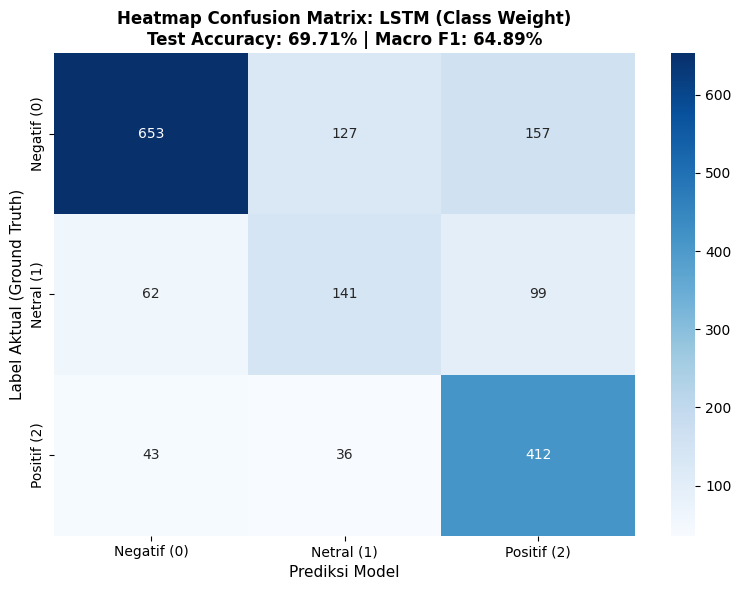

In [9]:
# d. Evaluasi Akurasi, Classification Report & Confusion Matrix Heatmap
y_pred_prob = model.predict(X_test_pad)
y_pred = np.argmax(y_pred_prob, axis=1)

acc = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro')
macro_prec = precision_score(y_test, y_pred, average='macro')
macro_rec = recall_score(y_test, y_pred, average='macro')

print("=" * 60)
print(f"HASIL EVALUASI MODEL: LSTM (CLASS WEIGHT)")
print("=" * 60)
print(f"Test Accuracy  : {acc*100:.2f}%")
print(f"Macro Precision: {macro_prec*100:.2f}%")
print(f"Macro Recall   : {macro_rec*100:.2f}%")
print(f"Macro F1-Score : {macro_f1*100:.2f}%\n")

target_names = ['Negatif (0)', 'Netral (1)', 'Positif (2)']
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=target_names, digits=4))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=target_names, yticklabels=target_names,
    cbar=True
)
plt.title(f'Heatmap Confusion Matrix: LSTM (Class Weight)\nTest Accuracy: {acc*100:.2f}% | Macro F1: {macro_f1*100:.2f}%', fontsize=12, fontweight='bold')
plt.xlabel('Prediksi Model', fontsize=11)
plt.ylabel('Label Aktual (Ground Truth)', fontsize=11)
plt.tight_layout()
plt.show()
